<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FCNN/CNN_big_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Tue Jul  1 14:39:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
print("GPU disponibile:", tf.config.list_physical_devices('GPU'))


GPU disponibile: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!git clone --branch feature/CNN --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import utils

# Importa simboli specifici (se vuoi)
from preprocessing.tf_dataset_loader import *
from models.utils import *

Cloning into 'chagas'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 169 (delta 34), reused 28 (delta 21), pack-reused 105 (from 1)
Receiving objects: 100% (169/169), 315.02 KiB | 4.04 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 127.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas

In [4]:
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Downloading...
From (original): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC
From (redirected): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC&confirm=t&uuid=b45c02e2-eaba-468d-8973-581ecd041eb6
To: /content/chagas/dataset.zip
100%|██████████| 623M/623M [00:04<00:00, 128MB/s]


In [5]:
#Carichiamo su array np
X_train_positive, y_train_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/train/positives')
X_train_negative, y_train_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/train/negatives')

X_val_positive, y_val_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/val/positives')
X_val_negative, y_val_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/val/negatives')

X_test_positive, y_test_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/test/positives')
X_test_negative, y_test_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/big_splitted_dataset/test/negatives')

In [6]:
print(f"TRAIN: {X_train_positive.shape[0]} positivi, {X_train_negative.shape[0]} negativi")
print(f"VAL: {X_val_positive.shape[0]} positivi, {X_val_negative.shape[0]} negativi")
print(f"TEST: {X_test_positive.shape[0]} positivi, {X_test_negative.shape[0]} negativi")


TRAIN: 3935 positivi, 3920 negativi
VAL: 557 positivi, 565 negativi
TEST: 1119 positivi, 1126 negativi


In [7]:
X_train, y_train = tf_dataset_loader.concatenate_and_shuffle((X_train_positive, y_train_positive), (X_train_negative, y_train_negative))
X_val, y_val = tf_dataset_loader.concatenate_and_shuffle((X_val_positive, y_val_positive), (X_val_negative, y_val_negative))
X_test, y_test = tf_dataset_loader.concatenate_and_shuffle((X_test_positive, y_test_positive), (X_test_negative, y_test_negative))

In [8]:
print(f"TRAIN SHAPE: {X_train.shape} - VALIDATION SHAPE: {X_val.shape} - TEST SHAPE: {X_test.shape}")

TRAIN SHAPE: (7855, 2800, 12) - VALIDATION SHAPE: (1122, 2800, 12) - TEST SHAPE: (2245, 2800, 12)


In [9]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

In [13]:
from models import layers

!git pull origin feature/CNN
%cd /content/chagas/src/models

from models import utils
from utils import *
import importlib
import utils

importlib.reload(utils)

from models import build_CNN
from build_CNN import build_ecg_model_with_spectrogram
import importlib
import build_CNN

importlib.reload(build_CNN)

from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC
from sklearn.utils import class_weight

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 7 (delta 4), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 674 bytes | 674.00 KiB/s, done.
From https://github.com/dokunoale/chagas
 * branch            feature/CNN -> FETCH_HEAD
   718a9e6..8c24776  feature/CNN -> origin/feature/CNN
Updating 718a9e6..8c24776
Fast-forward
 src/models/utils.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)
/content/chagas/src/models


In [16]:
model = build_CNN.build_ecg_model_with_spectrogram (dropout_rate=0.5)

#compiliamo il modello
model.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("1_CNN")

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    callbacks=callback)

Epoch 1/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5717 - auc: 0.5927 - loss: 0.8446
Epoch 1: val_auc improved from -inf to 0.76665, saving model to 1_CNN_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.5719 - auc: 0.5930 - loss: 0.8439 - val_accuracy: 0.7014 - val_auc: 0.7667 - val_loss: 0.6410 - learning_rate: 0.0010
Epoch 2/50
237/246 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6598 - auc: 0.7363 - loss: 0.6043
Epoch 2: val_auc improved from 0.76665 to 0.78299, saving model to 1_CNN_best_model.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6607 - auc: 0.7367 - loss: 0.6038 - val_accuracy: 0.6105 - val_auc: 0.7830 - val_loss: 0.6591 - learning_rate: 0.0010
Epoch 3/50
241/246 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6920 - auc: 0.7659 - loss: 0.5692
Epoch 3: val_auc did not improve from 0.78299
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6920 - auc: 0.7659 - loss: 0.5692 - val_accuracy: 0.5749 - val_auc: 0.765

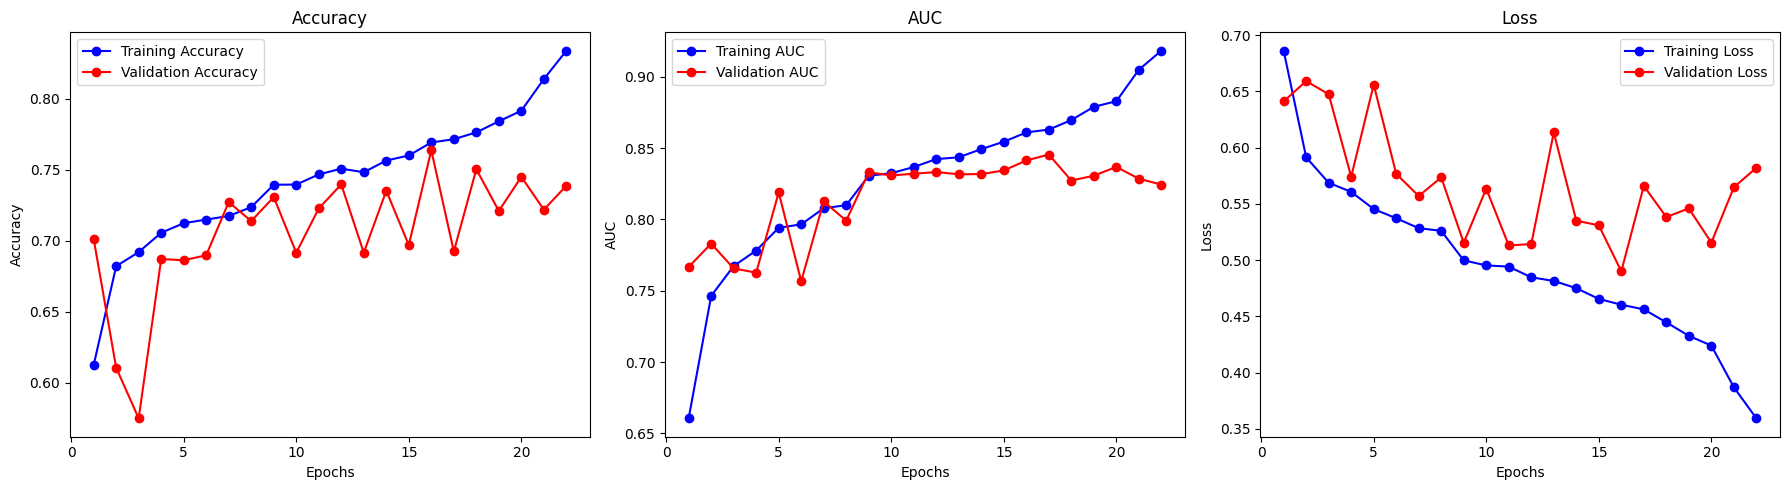

In [17]:
utils.plot_training_metrics(history)

In [18]:
#Facciamo le predizioni
y_pred_proba_val = model.predict(X_val).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_val, y_pred_proba_val)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_proba_test = model.predict(X_test).flatten()
y_pred_binary = (y_pred_proba_test >= optimal_threshold).astype(int)


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step
Soglia ottimale: 0.263
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


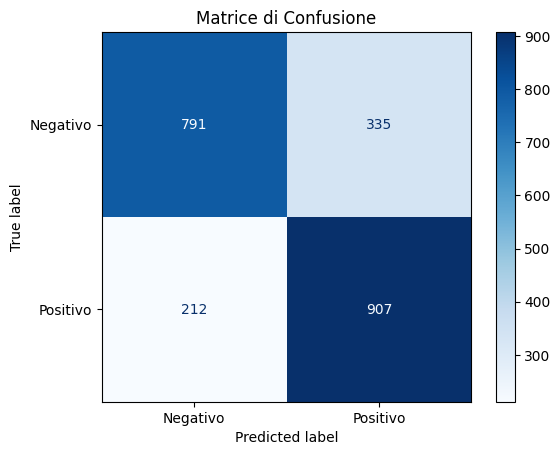

In [19]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

In [20]:
def find_threshold_for_min_recall(y_true, y_pred_proba, min_recall=0.80):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    valid_indices = [i for i, val in enumerate(tpr) if val >= min_recall]
    if not valid_indices:
        print("Nessuna soglia raggiunge la recall minima richiesta.")
        return None
    # Prendi la soglia con il più basso FPR tra quelli con recall >= min_recall
    best_idx = min(valid_indices, key=lambda i: fpr[i])
    threshold = thresholds[best_idx]
    print(f"Soglia con recall >= {min_recall}: {threshold:.3f}")
    return threshold


#Facciamo le predizioni
y_pred_proba_val = model.predict(X_val).flatten()

#Troviamo la soglia ottimale
optimal_threshold_min_rec = find_threshold_for_min_recall(y_val, y_pred_proba_val)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_proba_test = model.predict(X_test).flatten()
y_pred_binary = (y_pred_proba_test >= optimal_threshold_min_rec).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Soglia con recall >= 0.8: 0.270
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


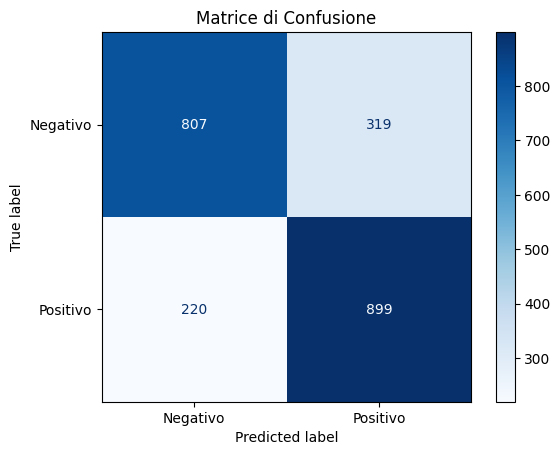

In [21]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

In [22]:
#Vediamo i risultati
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

acc = accuracy_score(y_test, y_pred_binary)
auc = roc_auc_score(y_test, y_pred_binary)

print(f"Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")

class_report1 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report1)
class_report1 = classification_report(y_test, y_pred_binary, output_dict=True )


Accuracy: 0.760
AUC: 0.760
              precision    recall  f1-score   support

    Negativo       0.79      0.72      0.75      1126
    Positivo       0.74      0.80      0.77      1119

    accuracy                           0.76      2245
   macro avg       0.76      0.76      0.76      2245
weighted avg       0.76      0.76      0.76      2245

